# Classification Using DL Model

In [2]:
from scipy.io import loadmat
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.matlib
from scipy import signal
from scipy.signal import welch
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
import os
import glob
from warnings import warn
from sklearn import metrics
plt.rc('font',family='Times New Roman')
import warnings 
warnings.filterwarnings('ignore')

In [18]:
# Function to compute FFT:
def apply_fft(x, fs):
    N = len(x) # number of samples in the signal.
    T = 1.0 / fs
    fft_coef = fft(x-np.mean(x)) # Obtain FFT coefficients after removing the mean (DC component) from the signal.
    xf = fftfreq(N, T)[:N//2] # Taking positive spectrum only.
    fft_positve = 2.0/N * np.abs(fft_coef[0:N//2]) # Multiply  abs(FFT coefficients) by 2 to compensate for positive spectrum and normalize by signal length.
    return xf, fft_positve

In [3]:
def make_dataset(data_src):
    files = glob.glob(data_src)
    dataset_df = []
    for file in files:
        dataset_df.append(pd.read_csv(file, header = None))
    dataset = pd.concat(dataset_df, ignore_index=True, axis= 1)
    return dataset.T

In [13]:
# Function to compute PSD

def compute_psd(signal, length, fs):
    seg_length =  length/2 # Segment length.
    overlap = seg_length/3 # overlap between segements (in number of samples)
    nfft_length = 1024 # # FFT length
    frequencies, psd = welch(signal,  fs = fs, window='hann', nperseg= seg_length, noverlap= overlap, nfft= nfft_length)
    
    return frequencies, psd

In [26]:
def spectral_features(signal, fs):
    # Calculate the Power Spectral Density (PSD) using Welch's method
    
    L = len(signal)
    
    frequencies, psd = compute_psd(signal, L,  fs)

    # Normalize the PSD to compute the spectral features correctly
    psd_norm = psd / np.sum(psd)

    # Calculate the Spectral Centroid
    spectral_centroid = np.sum(frequencies * psd_norm)

    # Calculate the Spectral Spread (second central moment)
    spectral_spread = np.sqrt(np.sum(((frequencies - spectral_centroid) ** 2) * psd_norm))
   

    # Calculate the Spectral Entropy
    spectral_entropy = entropy(psd)
    
    peak_freq = frequencies[np.argmax(psd)] # peak freq.
    
    peak_pwr = np.max(psd) # Peak amp.
    

    return spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr

## Dataset

In [6]:
data_path = ("./data/") # path to the 4 folders.
A  = make_dataset(os.path.join(data_path,  'A/*'))
B  = make_dataset(os.path.join(data_path,  'B/*'))
C  = make_dataset(os.path.join(data_path,  'C/*'))
D  = make_dataset(os.path.join(data_path,  'D/*'))
E  = make_dataset(os.path.join(data_path,  'E/*'))

In [7]:
normal = pd.concat([A, B]).reset_index(drop=True).to_numpy()
interictal = pd.concat([C, D]).reset_index(drop=True).to_numpy()
ictal = E.to_numpy()

In [8]:
num_samples =500 # Length of input segment
###########################################
fs =  173.61; # Sampling freq.

In [9]:
# Segmenting EEG signals:

data = normal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
normal = np.array(slices).reshape(int(num_segments), num_samples)
data = interictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
interictal = np.array(slices).reshape(int(num_segments), num_samples)
data = ictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
ictal = np.array(slices).reshape(int(num_segments), num_samples)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

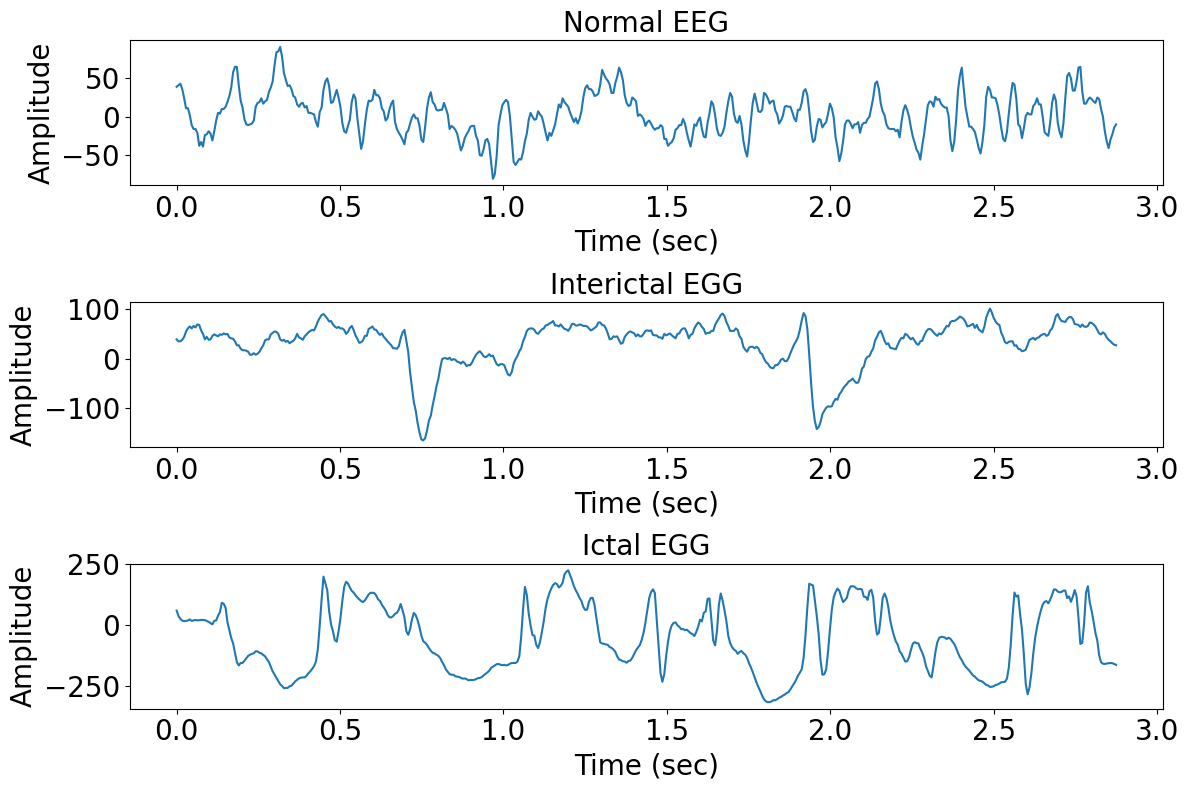

In [77]:
# Sample EEG signals representing the three classes of the UoB dataset.

index = 0

normal_EEG = normal[index]
interictal_EGG = interictal[index]
ictal_EGG = ictal[index]
time = np.arange(0.0, len(normal_EEG), 1.0)/fs
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, normal_EEG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Normal EEG", fontsize = 20)
plt.subplot(3, 1, 2)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, interictal_EGG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Interictal EGG", fontsize = 20)
plt.subplot(3, 1, 3)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, ictal_EGG)
plt.xlabel('Time (sec)', fontsize =20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Ictal EGG", fontsize = 20)
plt.tight_layout()
plt.show()

In [11]:
normal_labels = np.zeros(len(normal))
interictal_labels = np.ones(len(interictal))
ictal_labels = np.ones(len(ictal))*2
X = np.concatenate( (normal, interictal, ictal) , axis=0, out=None)
Y = np.concatenate( (normal_labels, interictal_labels, ictal_labels ) , axis=0, out=None)
print("data set features size:", X.shape)
print("data set labels size:", Y.shape)
print(X.shape)

data set features size: (4095, 500)
data set labels size: (4095,)
(4095, 500)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


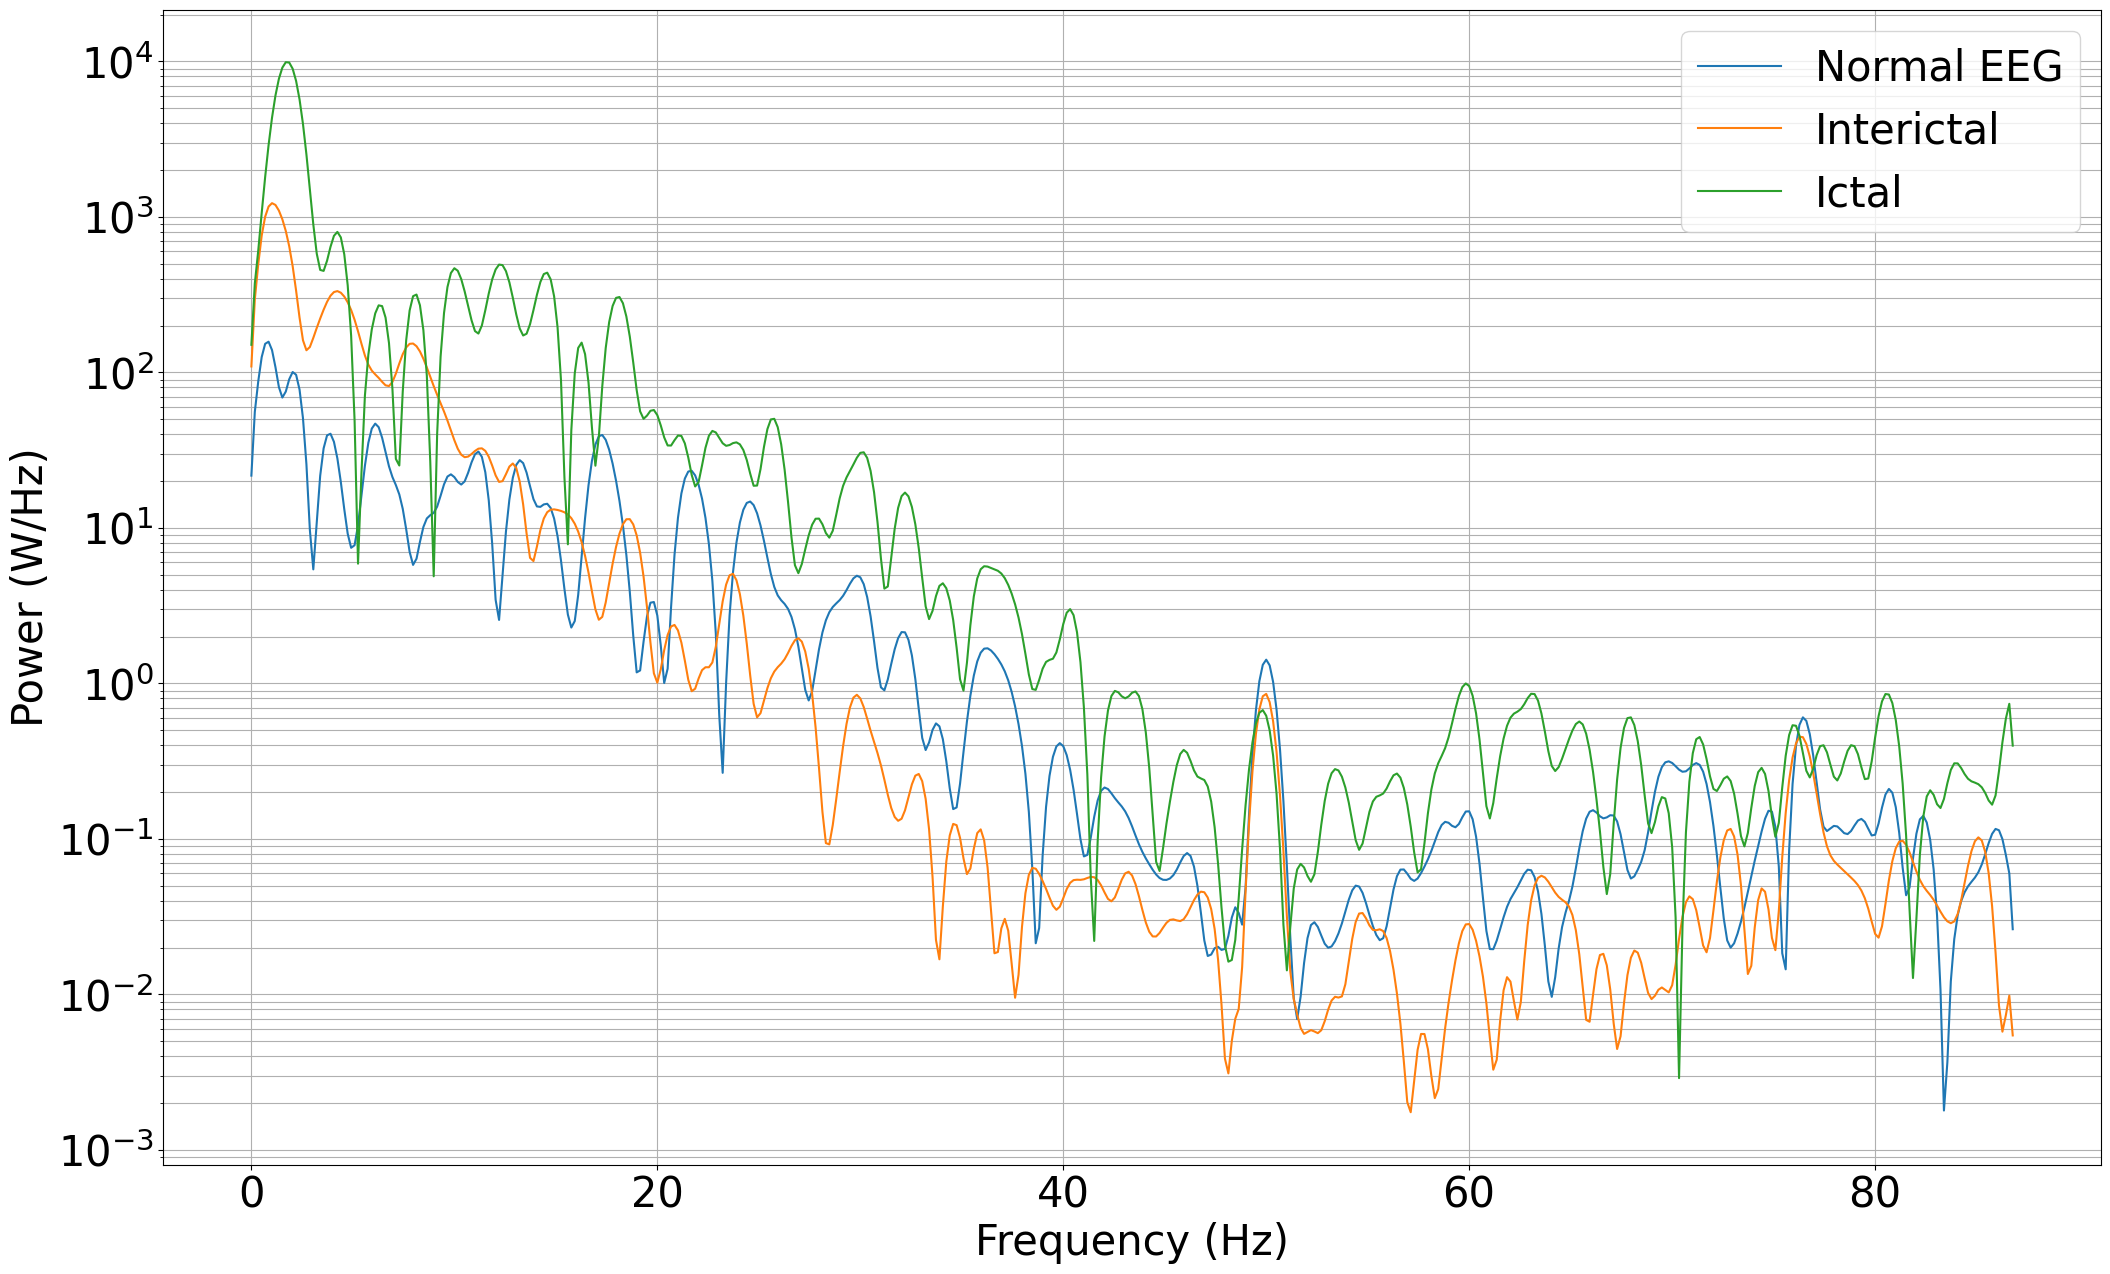

In [14]:
# Samples of estimated PSDs representing the three classes of the UoB dataset.

f1, psd1 = compute_psd(normal[index], len(normal[index]),  fs)
f2, psd2 = compute_psd(interictal[index],len(interictal[index]),   fs)
f3, psd3 = compute_psd(ictal[index],len(interictal[index]),   fs)


plt.figure(figsize=(25, 15))
plt.grid(True, which ="both")
plt.semilogy(f1, psd1, label = 'Normal EEG')
plt.semilogy(f2, psd2, label = 'Interictal')
plt.semilogy(f3, psd3, label = 'Ictal')

plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.legend(fontsize=30)
plt.show()

In [78]:
# Design of  a band-pass filter with pass and cut-off frequencies of 0.5 HZ and 30 Hz:

from scipy.signal import butter, filtfilt

N = 4  # Filter order. Generally, a higher order will have a steeper roll-off

# Butterworth band-pass filter design
b, a = butter(N, [0.5, 30],fs =fs,  btype='band', analog=False) # a & b are filter coefficients

In [16]:
# Filtering:
signal = X[0]

# Apply the filter to the signal
filtered_signal = filtfilt(b, a, signal)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

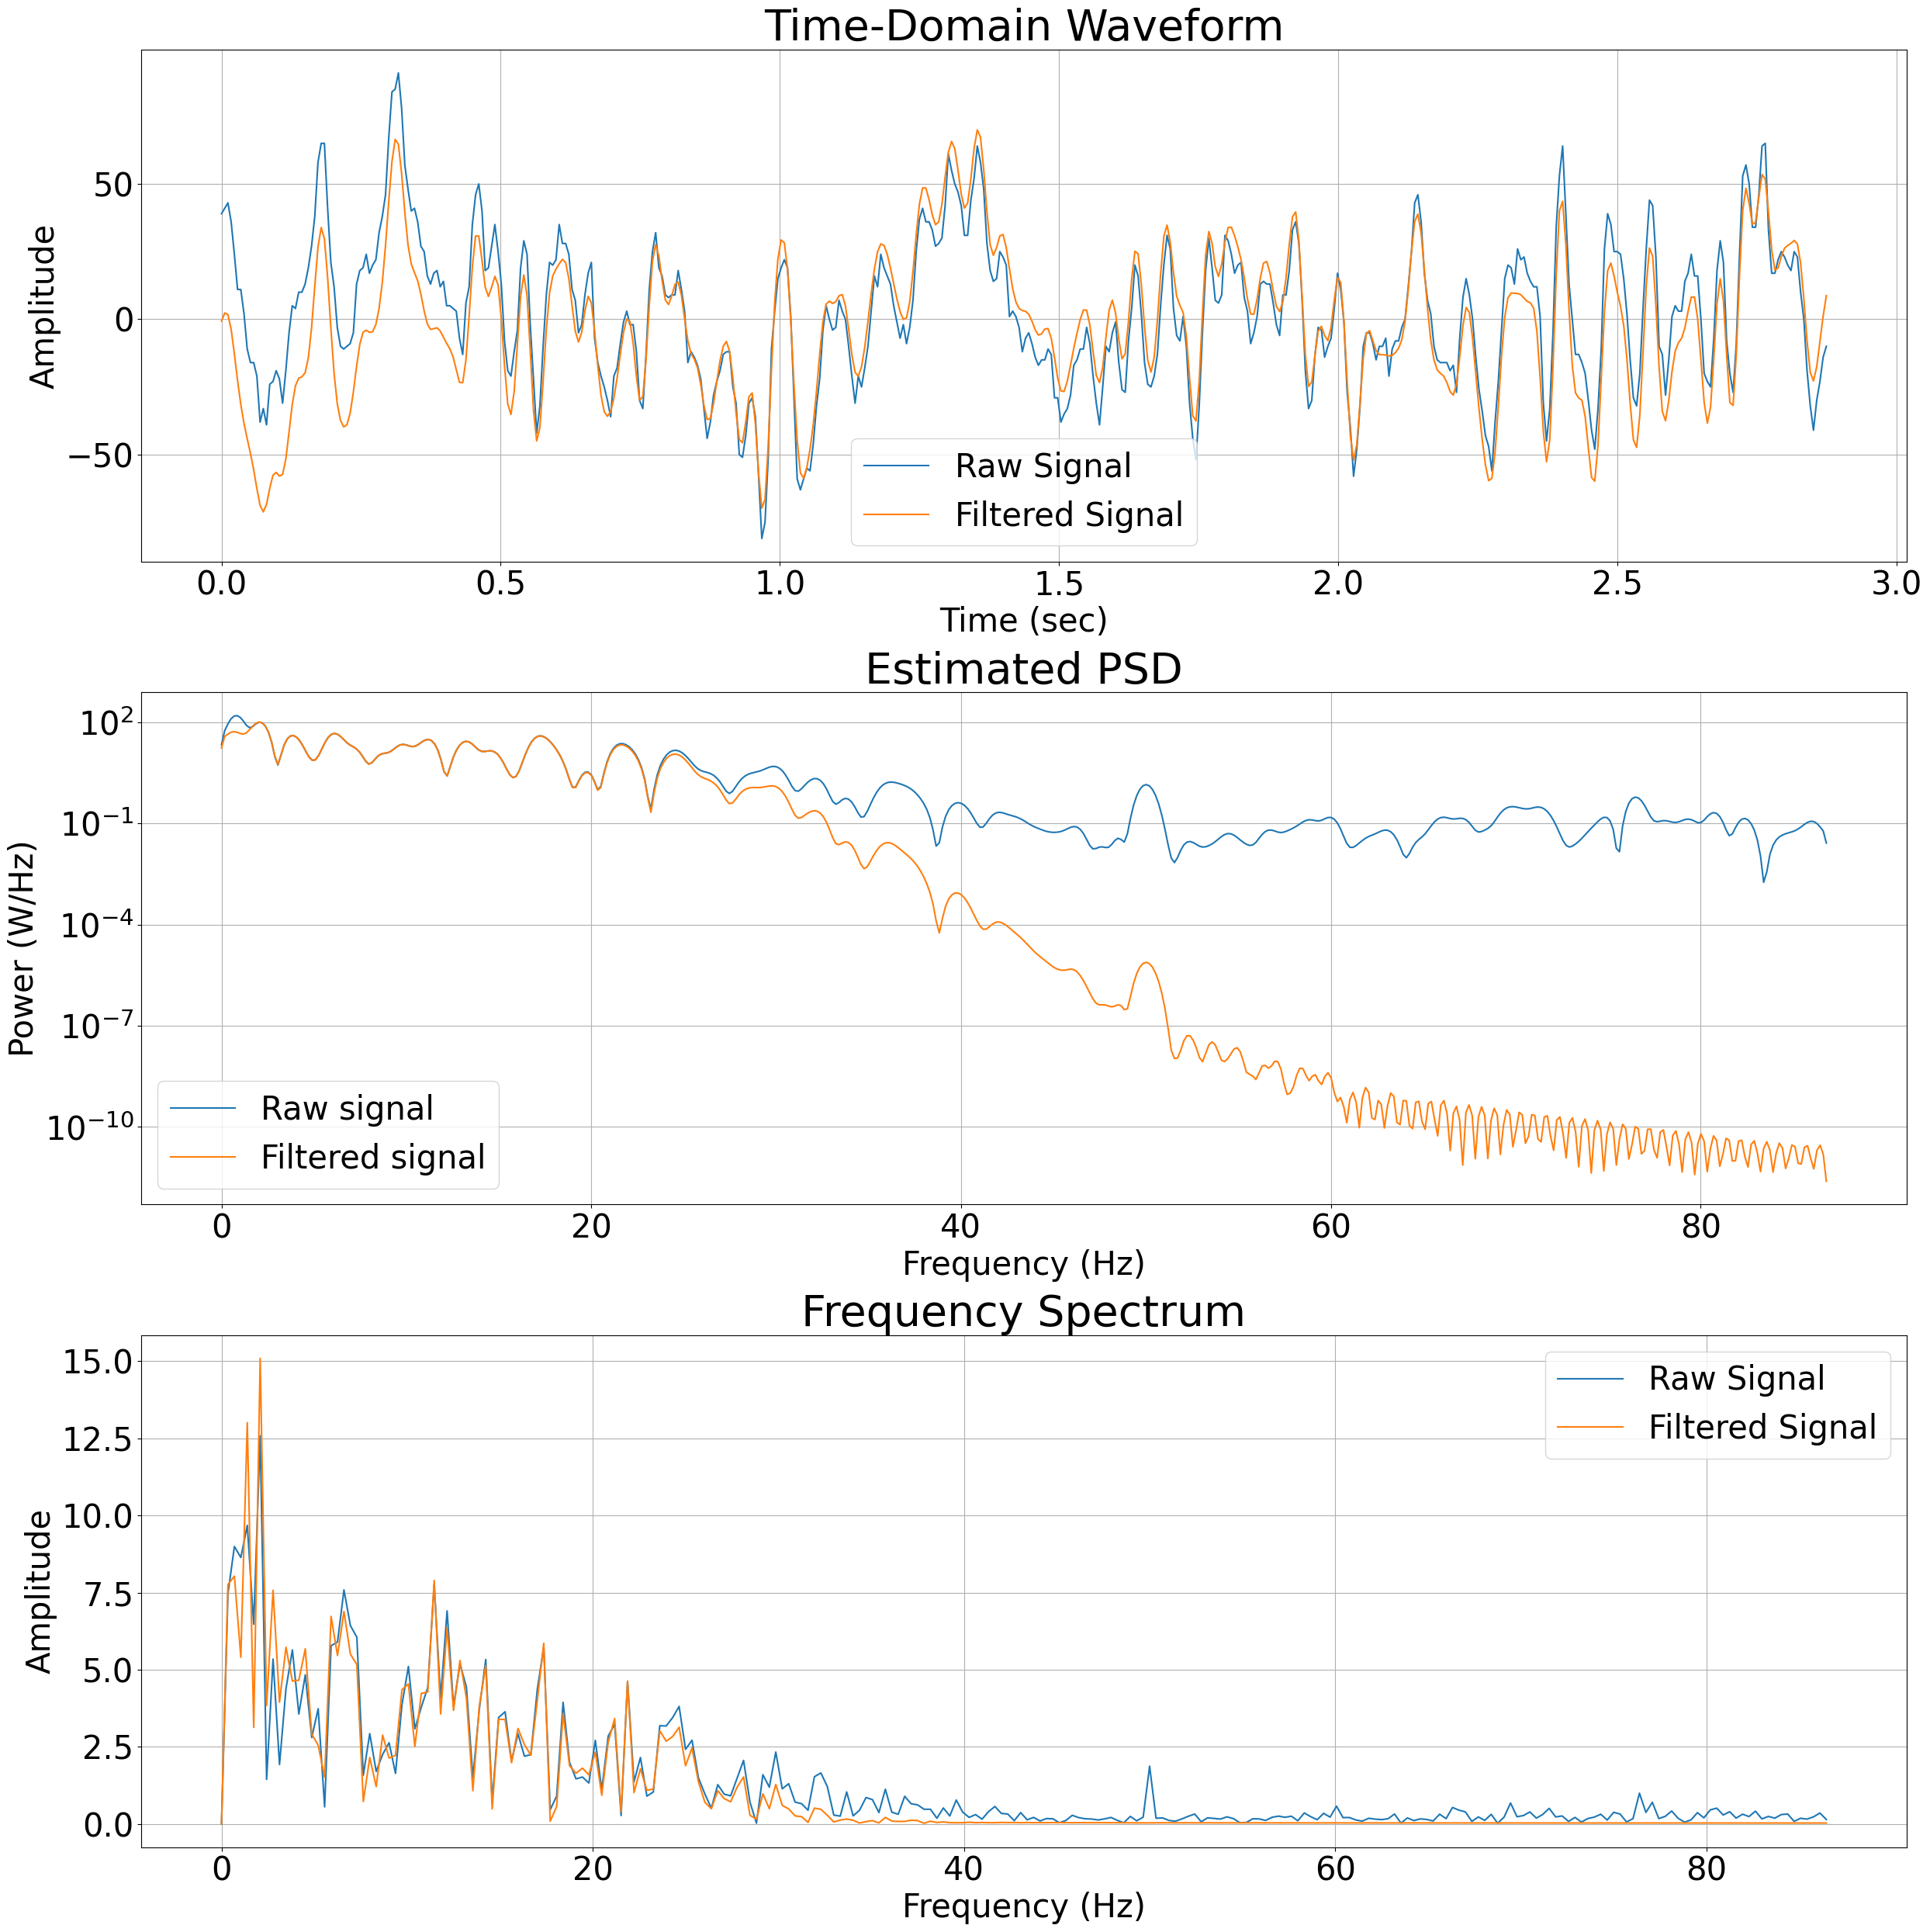

In [19]:
# A comparison between unfiltered (raw) and filtered EEG signals.

time = np.arange(0.0, len(signal), 1.0)/fs

f1, psd1 = compute_psd(signal, len(signal), fs)
f2, psd2 = compute_psd(filtered_signal,len(filtered_signal),  fs)

f_raw, x_raw = apply_fft(signal, fs)
f_lp, x_lp = apply_fft(filtered_signal, fs)

plt.figure(figsize=(25, 25))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.plot(time, signal, label='Raw Signal')
plt.plot(time, filtered_signal, label='Filtered Signal')
plt.xlabel('Time (sec)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Time-Domain Waveform', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)


plt.subplot(3, 1, 2)
plt.semilogy(f1, psd1, label = 'Raw signal')
plt.semilogy(f2, psd2, label = 'Filtered signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.title('Estimated PSD', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)


plt.subplot(3, 1, 3)
plt.plot(f_raw, x_raw, label='Raw Signal')
plt.plot(f_lp, x_lp, label='Filtered Signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Frequency Spectrum', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
# Feature calculations

num_signals = len(X)
num_features = 5
feature_matrix = np.zeros((num_signals, num_features))  # Initialize a matrix to store the features

# Loop over 10 signals
for i in range(num_signals):
    sig_in = filtfilt(b, a, X[i])
    #sig_in =X[i]
    spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr = spectral_features(sig_in, fs)
    
    # Store the features in the matrix
    feature_matrix[i, :] = [spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr]
    
print(feature_matrix.shape)

(4095, 5)


In [ ]:
from skopt import Optimizer
from skopt import BayesSearchCV 
from skopt.space import Real, Categorical, Integer
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder

In [120]:
labels = Y
labels.shape

(4095,)

In [124]:
labels = np.array(labels).reshape(-1,1)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
one_hot_label = encoder.fit_transform(labels)

one_hot_label.shape

(4095, 3)

In [125]:
timesteps = 173
X = []
y = []

for i in range(len(feature_matrix) - timesteps):
    X.append(feature_matrix[i : i + timesteps, :])  # Capture 173 consecutive timesteps
    y.append(one_hot_label[i + timesteps])  # Label for last timestep in window

X = np.array(X)
y = np.array(y)

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle = True, stratify = y, random_state = 42)

In [128]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [142]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.config.experimental import list_physical_devices, set_memory_growth
from tensorflow import device
from tensorflow.keras.callbacks import ModelCheckpoint

## LSTM

In [130]:
timesteps = 173
features = 5

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, features)),  # LSTM layer with 64 units
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(32),# Another LSTM layer
    Dense(16, activation='relu'),  # Dense layer
    Dense(3, activation='softmax')  # Output layer for binary classification
])
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [131]:
checkpoint = ModelCheckpoint(
    'weights/RNN_LSTM.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [133]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size = 20,
        callbacks= [early_stopping,checkpoint]
    )

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.9967 - loss: 0.0124 - val_accuracy: 0.9927 - val_loss: 0.0157
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9991 - loss: 0.0060 - val_accuracy: 0.9964 - val_loss: 0.0117
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9984 - loss: 0.0082 - val_accuracy: 0.9964 - val_loss: 0.0223
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9863 - loss: 0.0370 - val_accuracy: 0.8400 - val_loss: 0.3063
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9577 - loss: 0.0966 - val_accuracy: 0.9927 - val_loss: 0.0115
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9913 - loss: 0.0277 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9939 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9946 - loss: 0.0211 - val_accu

In [134]:
model.load_weights('weights/RNN_LSTM.weights.h5')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9920 - loss: 0.0254
Test Loss: 0.025949496775865555
Test Accuracy: 0.9923534393310547


In [136]:
y_pred = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step 


In [139]:
# Converting to class labels
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)


AxisError: axis 1 is out of bounds for array of dimension 1

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

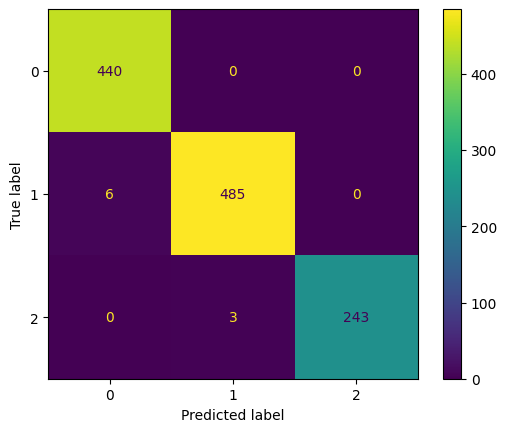

In [140]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1, 2]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()

## GRU

In [143]:
timesteps = 173
features = 5

model = Sequential([
    GRU(64, return_sequences=True, input_shape=(timesteps, features)),  # LSTM layer with 64 units
    GRU(64, return_sequences=True),
    GRU(32, return_sequences=True),
    GRU(32),# Another LSTM layer
    Dense(16, activation='relu'),  # Dense layer
    Dense(3, activation='softmax')  # Output layer for binary classification
])
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [144]:
checkpoint = ModelCheckpoint(
    'weights/RNN_GRU.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [145]:
with device('/GPU:0'):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size = 20,
        callbacks= [early_stopping,checkpoint]
    )

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.5590 - loss: 0.8127 - val_accuracy: 0.9673 - val_loss: 0.1789
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9294 - loss: 0.2385 - val_accuracy: 0.9818 - val_loss: 0.0820
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9580 - loss: 0.1341 - val_accuracy: 0.9818 - val_loss: 0.0374
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9587 - loss: 0.1001 - val_accuracy: 1.0000 - val_loss: 0.0253
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9778 - loss: 0.0696 - val_accuracy: 0.9964 - val_loss: 0.0264
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9749 - loss: 0.0656 - val_accuracy: 0.9236 - val_loss: 0.1672
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9706 - loss: 0.0698 - val_accuracy: 0.9964 - val_loss: 0.0114
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9895 - loss: 0.0299 - val_acc

In [148]:
model.load_weights('weights/RNN_GRU.weights.h5')
y_test = np.array(y_test).reshape(-1,1)
y_test = encoder.fit_transform(y_test)
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9980 - loss: 0.0056    
Test Loss: 0.006119069177657366
Test Accuracy: 0.99745112657547


In [149]:
y_pred = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step 


In [150]:
# Converting to class labels
y_test = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

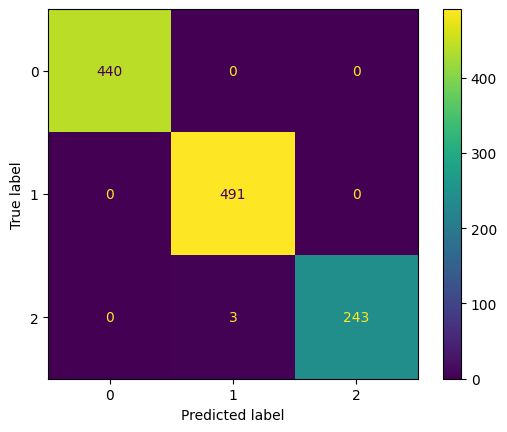

In [151]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
display_labels = [0, 1, 2]  # Adjust based on your class labels
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
cm_display.plot()